In [1]:
import numpy as np
import matplotlib as mpl
#mpl.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-deep')
plt.rcParams['axes.facecolor'] = 'white'

from sklearn import manifold
from sklearn.decomposition import PCA

In [13]:
dist_matrix = np.loadtxt('../../data/bn_distances/distances_dowker_minpurge.csv', 
                         delimiter = ',')

/home/munozram/Desktop/TDA/ve/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


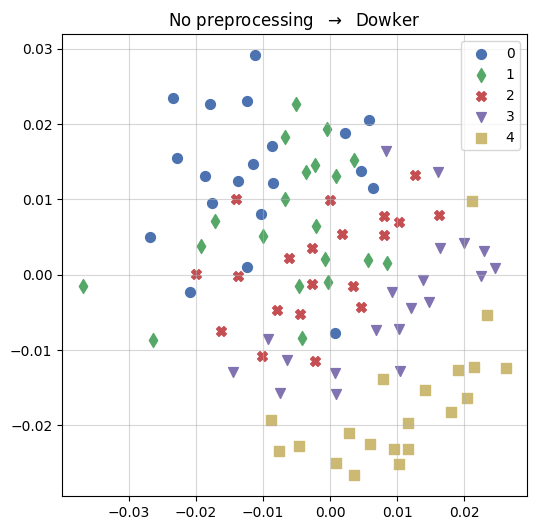

/home/munozram/Desktop/TDA/ve/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


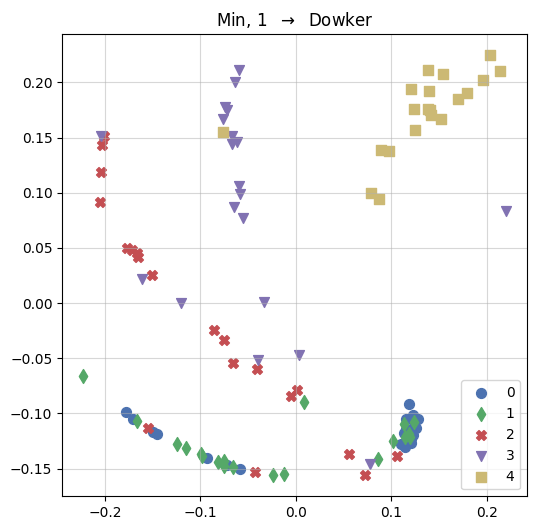

/home/munozram/Desktop/TDA/ve/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


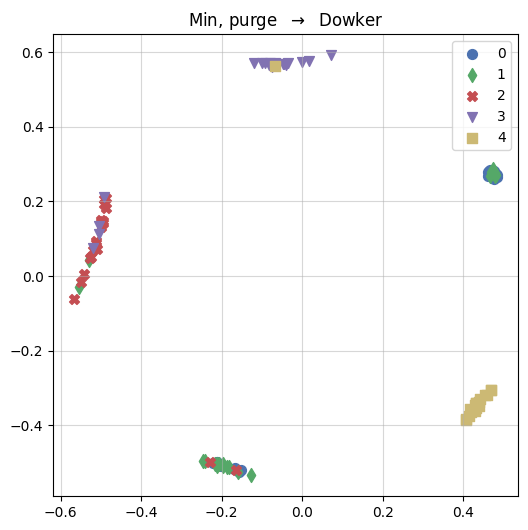

/home/munozram/Desktop/TDA/ve/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


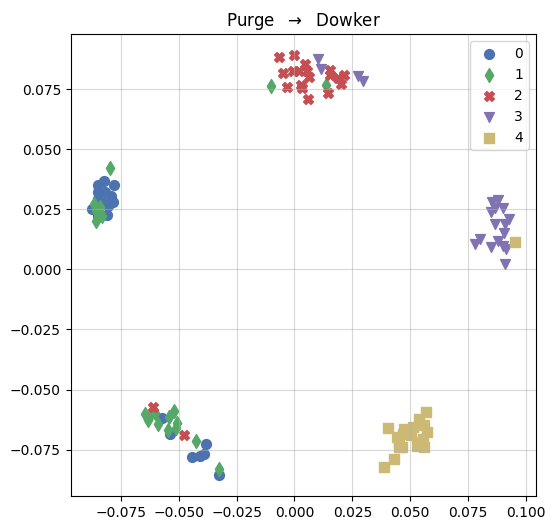

/home/munozram/Desktop/TDA/ve/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


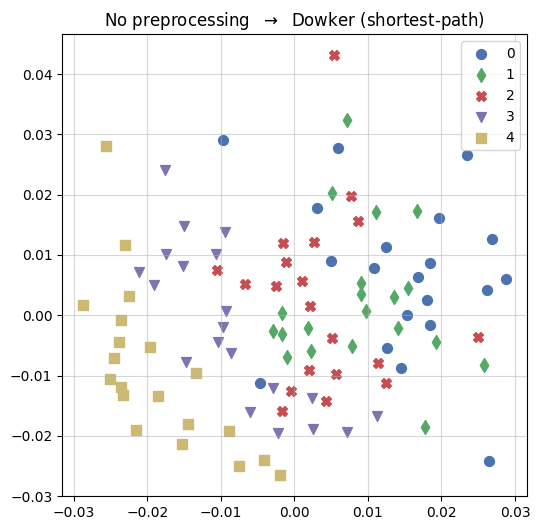

/home/munozram/Desktop/TDA/ve/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


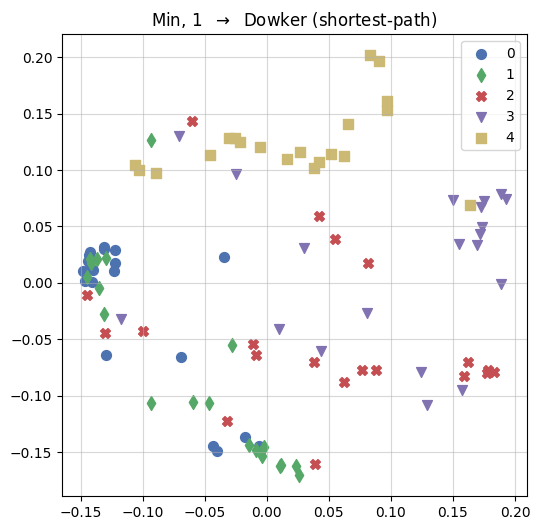

/home/munozram/Desktop/TDA/ve/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


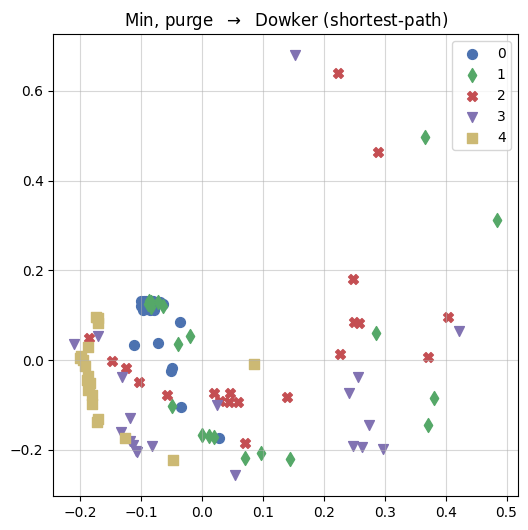

/home/munozram/Desktop/TDA/ve/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


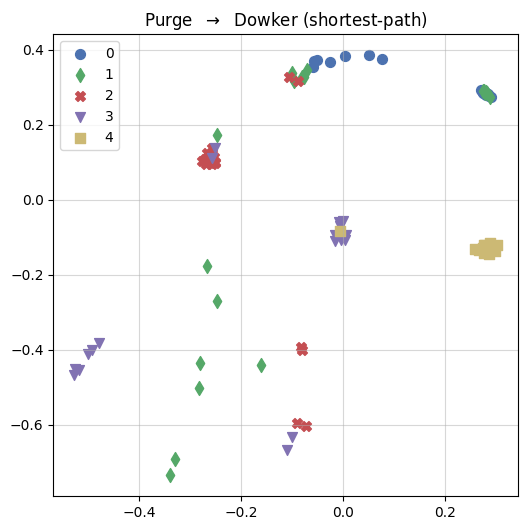

In [14]:
#For loop to compute all MDS

preprocs = ['original','min1', 'minpurge', 'purge']

nice_titles = {'ripsmax': 'Rips (max)',
               'ripsmin': 'Rips (min)',
               'dowker': 'Dowker',
               'dowkershort': 'Dowker (shortest-path)',
               'walklen': 'Walk-length', 
               'original': 'No preprocessing',
               'min1': 'Min, 1',
               'minpurge': 'Min, purge',
               'purge': 'Purge',
               'originalshort': 'No preprocessing',
               'min1short': 'Min, 1',
               'minpurgeshort': 'Min, purge',
               'purgeshort': 'Purge',}

#for method in ['ripsmax', 'ripsmin', 'dowker', 'dowkershort', 'walklen']:
for method in ['dowker', 'dowkershort']:
    method_title = method
    if method == 'dowkershort':
        preprocs = [p+'short' for p in preprocs]
        method = 'dowker'

    for prep in preprocs:
        dist_matrix = np.loadtxt('../../data/bn_distances/distances_'+method+'_'+prep+'.csv', 
                         delimiter = ',')

        dist_matrix[dist_matrix==np.inf] = np.max(dist_matrix[np.isfinite(dist_matrix)]) * 1.5

        mds = manifold.MDS(
            n_components=2,
            max_iter=500,
            eps=1e-9,
            #random_state=seed,
            dissimilarity="precomputed",
            normalized_stress='auto'
        )
        pos = mds.fit(dist_matrix).embedding_

        markers = ['o','d','X','v','s']

        plt.figure(figsize=(6, 6))
        # Plot for each class
        for h in range(5):
            plt.scatter(pos[20*h:20*(h+1), 0], pos[20*h:20*(h+1), 1],
                        s=50, marker=markers[h], label=str(h))
        plt.grid(alpha=0.5)
        plt.legend()
        
        plt.title(nice_titles[prep] + '  $\\rightarrow$  ' + nice_titles[method_title])
        plt.show()
        #plt.savefig('../figures/MDS_'+method+'_'+prep+'.png', bbox_inches='tight', dpi=500);
        plt.close()

In [15]:
mds = manifold.MDS(
    n_components=2,
    max_iter=500,
    eps=1e-9,
    #random_state=seed,
    dissimilarity="precomputed",
    normalized_stress='auto'
)
pos = mds.fit(dist_matrix).embedding_

#clf = PCA(n_components=2)
#pos = clf.fit_transform(pos)

/home/munozram/Desktop/TDA/ve/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Text(0.5, 1.0, 'No preprocessing  $\\rightarrow$  Dowker')

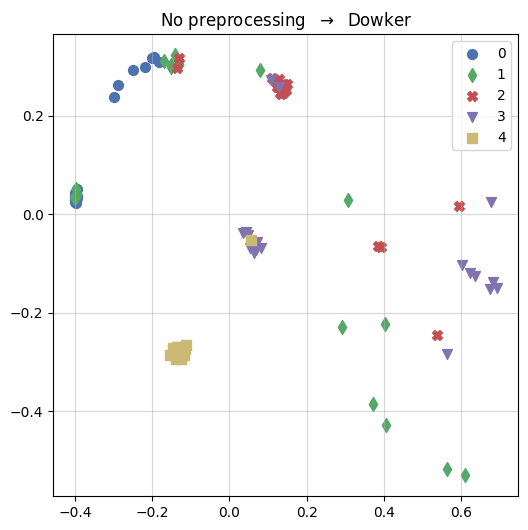

In [16]:
markers = ['o','d','X','v','s']

plt.figure(figsize=(6, 6))
for h in range(5):
    plt.scatter(pos[20*h:20*(h+1), 0], pos[20*h:20*(h+1), 1],
                #color="turquoise", 
                s=50, marker=markers[h], label=str(h))
plt.grid(alpha=0.5)
plt.legend()

plt.title('No preprocessing  $\\rightarrow$  Dowker')
#plt.savefig('../figures/MDS_dowker_original.png', bbox_inches='tight', dpi=500);